# Week 5 Day 3 Lab

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3. 
    - If $f'(x_0)>0$, move to $x_0-\epsilon$. 
    - If $f'(x_0)<0$, move to $x_0+\epsilon$. 
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

In [4]:
import sympy as sp
import numpy as np
import math


In [30]:
def grad(f, start):
    x = sp.symbols('x')
    i = int(input("Enter a number for iterations"))
    der = sp.diff(f, x)
    for j in range(i):
        if (der.subs(x, start) > 0):
            start -= 1
        elif (der.subs(x, start) < 0):
            start =+ 1
        else:
            start = start
    return start

x = sp.symbols('x')
f = x**2 + 6*x +9

y = grad(f, 9)
y

Enter a number for iterations 1000


-3

### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [38]:
j = grad(f,0)
%timeit j


Enter a number for iterations 50


18.8 ns ± 0.562 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [47]:
from scipy.optimize import minimize
def g(x):
    return x**2 + 6*x +9

result = minimize(g, x0 = 0)
%timeit result.x[0]

227 ns ± 10.8 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

In [56]:
hours = np.array([1, 2, 3, 4, 5, 6, 7,8, 9, 10])
heat = np.array([52, 50, 63, 66, 70, 76, 81, 90, 91 , 95])
def loss(params):
    a,b = params
    prediction = a*hours+b
    return np.sum((heat-prediction)**2)

result = minimize(loss,
                  [1,1])

%timeit result.x

148 ns ± 2.64 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [57]:
m, b = np.polyfit(hours,
                  heat,
                  1)
%timeit m, b

34.5 ns ± 0.645 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


### Problem 4 
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.

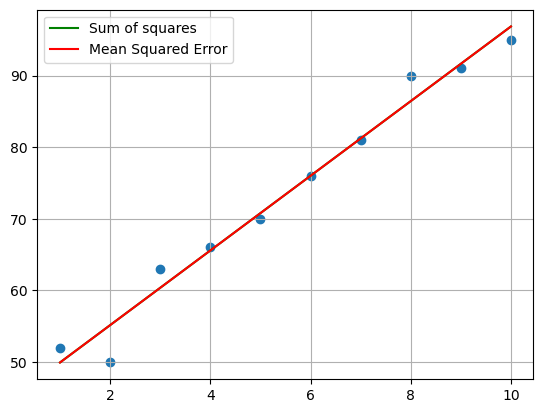

In [70]:
# Mean Squared Error
import matplotlib.pyplot as plt
def loss_2(params):
    a,b = params
    prediction = a*hours + b
    return (np.sum((heat - prediction)**2))/len(heat)
result1= minimize(loss_2,
                  [1,1])

m2, b2 = result1.x
plt.scatter(hours, heat)
plt.plot(hours,
         m*hours + b,
         label = "Sum of squares",
         color = 'green')
plt.plot(hours,
         m2*hours + b2,
         label = "Mean Squared Error",
         color = 'red')

plt.legend()
plt.grid()
plt.show()
#looks about the same to me 

In [69]:
result1.x

array([ 5.21212121, 44.7333333 ])